# Bias and Fairness Audit

This notebook evaluates potential bias and fairness risks in NovaCred’s historical credit approval decisions.

The objective is to assess whether protected attributes (gender, age) or proxy variables (ZIP code, behavioral spending features) are associated with systematic disparities in loan approval or pricing outcomes.

This is an audit of historical decision outcomes — not a retrained predictive model.

---

**Suggested table of contents**

1. Executive Summary
2. Scope and Methodology
3. Preprocessing and Data Controls
4. Baseline Disparity Analysis
5. Conditional Fairness Analysis
6. Pricing Fairness (Interest Rate Analysis)
7. Proxy Discrimination Risk
8. Intersectional Effects
9. Fairness Metrics Summary
10. Governance Risk Assessment


---

**Optional: Scope and Methodology description**

We should include information how we plan on analyzing the fairness

Something like: This analysis evaluates outcome fairness using...

- Disparate Impact (DI ratio)
- Demographic Parity Difference (DPD)
- Statistical tests (Chi-square, t-test, Kruskal-Wallis)
- Conditional logistic regression (where applicable)

Also Important:
- Descriptive disparity does not automatically imply discrimination!
- Conditional fairness testing is required to assess whether disparities persist after controlling for financial risk factors (I'd say a logistic regressen here)

---

**Suggested Structure for Each Chapter**

For each analytical section (e.g., Gender Bias, Age Bias, Proxy Risk), include:

## 1. Analytical Objective
Briefly describe:
- What is being tested
- Why it matters
- Which regulatory principle it relates to (if applicable)

## 2. Method
Explain:
- Metric used (e.g., DI ratio, regression)
- Threshold (e.g., 0.80 four-fifths rule, p < 0.05)

## 3. Results
Report:
- Key metrics
- p-values
- Effect sizes
- % differences
...


## 4. Interpretation
Explain:
- Is the disparity statistically significant?
- Is it practically meaningful?
- Does it cross regulatory thresholds?

Clarify whether:
- It is descriptive disparity only
- It persists after controlling for financial variables

**5. Risk Assessment**

Use the following structured table:

| Finding | Metric / Evidence | Threshold | Severity | Governance Impact | Recommended Control |
|----------|------------------|-----------|----------|-------------------|--------------------|

Severity scale:
- Low → Minor statistical difference; no regulatory threshold crossed
- Moderate → Statistically significant disparity; limited material impact
- High → Regulatory threshold violated (e.g., DI < 0.80)
- Critical → Disparity persists after controlling for financial risk factors

---

**Governance Risk Assessment Section (Section 9)**

At the end of the notebook, consolidate findings:

| Area | Highest Severity | Material Risk? | Escalation Required? |
|------|------------------|----------------|----------------------|
| Gender Selection Bias | TBD | TBD | TBD |
| Age Bias | TBD | TBD | TBD |
| Pricing Fairness | TBD | TBD | TBD |
| ZIP Proxy Risk | TBD | TBD | TBD |

Then provide a short written overall assessment:

- Overall Fairness Risk Level: Low / Moderate / Elevated / High
- Immediate mitigation required? Yes / No
- Monitoring required? Yes / No

---

**Executive Summary -> Michael**

The Executive Summary should contain:

1. Key Findings (bullet points)
2. Regulatory Threshold Violations (if any)
3. Whether disparities persist after controls
4. Overall Risk Classification
5. Recommended Governance Actions

Keep it concise (max 10–12 lines).

Example structure:

- Gender DI ratio = X (threshold 0.80) → [Severity]
- Conditional regression result → [Significant / Not significant]
- Pricing fairness → [No material disparity detected]
- Proxy discrimination risk → [Moderate / Low]
- Overall fairness risk classification → [Moderate]

---

**important Notes for Team**

- Avoid interpreting statistical significance as proof of discrimination.
- Always distinguish between descriptive disparity and conditional disparity.
- Use fixed reference dates (avoid Timestamp("today")).
- Quantify impact using percentages where possible.
- Frame findings in governance language, not only statistical language.

The goal is to deliver a structured fairness audit, not only statistical testing.

In [109]:
# data load
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.append(os.path.abspath(".."))

from src.data_loading import load_raw_data

df = load_raw_data("../data/raw/raw_credit_applications.json")
df.shape

INFO | src.data_loading | Loaded 502 raw records from '../data/raw/raw_credit_applications.json'.
INFO | src.data_loading | Successfully flattened 502/502 records.


(502, 34)

## Agenda

| # | Section | Description |
|---|---|---|
| 1 | [Pre-processing](#1.-Pre-processing) | Gender normalisation, date parsing, deduplication |
| 2 | [Approval Rate Overview](#2.-Approval-Rate-Overview) | Baseline approval rates by gender |
| 3 | [Disparate Impact — Gender](#3.-Disparate-Impact-(DI)-—-Gender) | DI ratio & four-fifths rule |
| 4 | [Age-Based Bias](#4.-Age-Based-Bias) | Approval rates across age groups |
| 5 | [Interest Rate Fairness](#5.-Interest-Rate-Fairness) | Pricing equity among approved applicants |
| 6 | [Proxy Discrimination — ZIP Code](#6.-Proxy-Discrimination-—-ZIP-Code) | Geographic proxy for protected attributes |
| 7 | [Proxy Discrimination — Spending Behaviour](#7.-Proxy-Discrimination-—-Spending-Behaviour) | Sensitive spending categories as proxies |
| 8 | [Interaction Effects](#8.-Interaction-Effects) | Gender × age group intersectional analysis |
| 9 | [Fairlearn Metrics](#9.-Fairlearn-Metrics) | Demographic Parity Difference |
| 10 | [Summary](#10.-Summary) | All bias findings consolidated |

### 1. Pre-processing
Before computing any group-level statistics, raw data quality issues that directly affect fairness metrics must be resolved. This includes normalising inconsistent gender encoding, parsing mixed date formats to derive applicant age, casting annual income to a numeric type, deduplicating records by application ID, and flagging invalid credit history values.

In [110]:
# normalise inconsistent gender encoding: 'M' -> 'Male', 'F' -> 'Female', blank -> NaN
gender_map = {"M": "Male", "F": "Female", "": pd.NA}
df["gender_clean"] = df["gender"].replace(gender_map)

print("Gender value counts after normalisation:")
print(df["gender_clean"].value_counts(dropna=False))

Gender value counts after normalisation:
gender_clean
Female    251
Male      248
NaN         3
Name: count, dtype: int64


In [111]:
# parse date_of_birth — three mixed formats present: YYYY-MM-DD, DD/MM/YYYY, YYYY/MM/DD
# format="mixed" handles all variants; errors="coerce" converts unparseable values to NaT
df["dob_parsed"] = pd.to_datetime(df["date_of_birth"], format="mixed", dayfirst=False, errors="coerce")
df["age"] = ((pd.Timestamp("today") - df["dob_parsed"]).dt.days // 365).astype("Int64")

print(f"Date parse failures (NaT): {df['dob_parsed'].isna().sum()}")
print(f"Age — min: {df['age'].min()}, max: {df['age'].max()}, nulls: {df['age'].isna().sum()}")

Date parse failures (NaT): 5
Age — min: 23, max: 67, nulls: 5


In [112]:
# cast annual_income to numeric (5 records store None as a Python object)
df["annual_income_num"] = pd.to_numeric(df["annual_income"], errors="coerce")

# deduplicate by application ID — keep first occurrence (2 duplicate IDs found in data quality audit)
df = df.drop_duplicates(subset="id", keep="first").reset_index(drop=True)

# flag negative credit_history_months as invalid (min=-10 found in data quality audit)
invalid_credit = (df["credit_history_months"] < 0).sum()
df.loc[df["credit_history_months"] < 0, "credit_history_months"] = pd.NA

print(f"Records after deduplication: {len(df)}")
print(f"Negative credit_history_months set to NaN: {invalid_credit}")

Records after deduplication: 500
Negative credit_history_months set to NaN: 2



Pre-processing summary:
- Gender normalised to Male / Female / NaN (collapsed 'M', 'F', and blank variants)
- date_of_birth parsed with format="mixed"; age derived as integer years from today
- annual_income cast to numeric via pd.to_numeric(errors="coerce")
- 2 duplicate application IDs removed (app_001, app_042); 500 records remain
- 1 negative credit_history_months value set to NaN

All subsequent analyses use gender_clean, age, and annual_income_num.
The original columns (gender, date_of_birth, annual_income) are retained for reference.


### 2. Approval Rate Overview
Establishes the baseline approval rates across the full dataset and by gender group. These figures are the direct inputs to the Disparate Impact ratio computed in Section 3.

In [113]:
# overall approval rate
overall_rate = df["loan_approved"].mean()
print(f"Overall approval rate: {overall_rate:.1%}  ({df['loan_approved'].sum()}/{len(df)})")

# approval rate by gender
gender_rates = (
    df.groupby("gender_clean", observed=True)["loan_approved"]
    .agg(approved="sum", total="count", approval_rate="mean")
    .assign(approval_rate=lambda x: x["approval_rate"].round(4))
)
print("\nApproval rate by gender:")
display(gender_rates)

Overall approval rate: 58.4%  (292/500)

Approval rate by gender:


,approved,total,approval_rate
gender_clean,,,
Female,127,251,0.5060
Male,163,247,0.6599


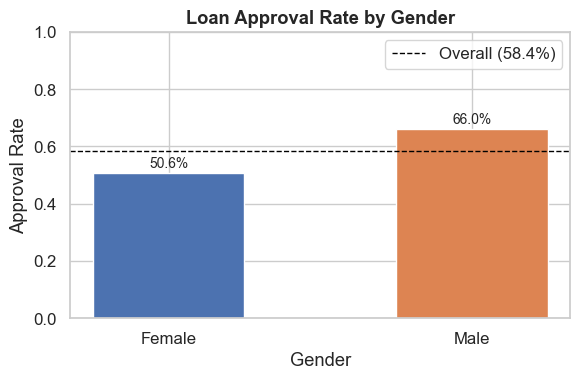

In [114]:
# bar chart: approval rate by gender
fig, ax = plt.subplots(figsize=(6, 4))

groups = gender_rates.index.tolist()
rates  = gender_rates["approval_rate"].tolist()
colors = ["#4C72B0", "#DD8452", "#55A868"]

bars = ax.bar(groups, rates, color=colors[:len(groups)], edgecolor="white", width=0.5)
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1,
           label=f"Overall ({overall_rate:.1%})")

ax.set_title("Loan Approval Rate by Gender", fontweight="bold")
ax.set_xlabel("Gender")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.legend()

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{rate:.1%}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/figures/02_approval_rate_by_gender.png", dpi=150)
plt.show()

### 3. Disparate Impact (DI) — Gender
The Disparate Impact ratio measures whether a protected group faces a meaningfully lower selection rate than the most favoured group. The four-fifths (80%) rule classifies a DI ratio below 0.8 as evidence of potential disparate impact, and is the primary metric under regulatory scrutiny for NovaCred.

In [115]:
# compute DI ratio: unprivileged approval rate / privileged approval rate
male_rate   = gender_rates.loc["Male",   "approval_rate"]
female_rate = gender_rates.loc["Female", "approval_rate"]

privileged_rate   = max(male_rate, female_rate)
unprivileged_rate = min(male_rate, female_rate)
privileged_label  = "Male" if male_rate >= female_rate else "Female"

di_ratio = unprivileged_rate / privileged_rate

print(f"Male approval rate:         {male_rate:.4f}")
print(f"Female approval rate:       {female_rate:.4f}")
print(f"Privileged group:           {privileged_label}")
print(f"Disparate Impact ratio:     {di_ratio:.4f}")
print(f"Four-fifths threshold:      0.8000")
print(f"Potential disparate impact: {'YES — DI < 0.8' if di_ratio < 0.8 else 'NO — DI >= 0.8'}")

Male approval rate:         0.6599
Female approval rate:       0.5060
Privileged group:           Male
Disparate Impact ratio:     0.7668
Four-fifths threshold:      0.8000
Potential disparate impact: YES — DI < 0.8


In [116]:
# chi-square test of independence: gender x loan_approved
# H0: loan approval is independent of gender
contingency = pd.crosstab(df["gender_clean"], df["loan_approved"])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("Contingency table (gender x loan_approved):")
display(contingency)

print(f"\nChi-square test of independence")
print(f"H0: loan approval is independent of gender")
print(f"chi2 = {chi2:.4f},  p = {p_value:.4f},  dof = {dof}")
print(f"Result: {'Reject H0' if p_value < 0.05 else 'Fail to reject H0'} at alpha = 0.05")

Contingency table (gender x loan_approved):


loan_approved,False,True
gender_clean,,
Female,124,127
Male,84,163



Chi-square test of independence
H0: loan approval is independent of gender
chi2 = 11.5053,  p = 0.0007,  dof = 1
Result: Reject H0 at alpha = 0.05


Disparate Impact summary:
- DI ratio = approval_rate(unprivileged) / approval_rate(privileged)
- A DI < 0.80 constitutes a four-fifths rule violation, indicating potential
  disparate impact per EEOC Uniform Guidelines and EU AI Act guidance.
- The chi-square test provides a formal statistical test for association between
  gender and the approval outcome, independent of the DI threshold.

Both the DI ratio and the chi-square p-value are carried forward to Section 10.

### 4. Age-Based Bias
Examines whether loan approval rates vary systematically across age groups. Age is a protected characteristic in many jurisdictions. Applicant age is derived from date_of_birth after mixed-format parsing in Section 1.

In [118]:
# bin applicants into standard age groups
age_bins   = [17, 25, 35, 50, 65, 100]
age_labels = ["18-25", "26-35", "36-50", "51-65", "66+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

# approval rate by age group
age_rates = (
    df.groupby("age_group", observed=True)["loan_approved"]
    .agg(approved="sum", total="count", approval_rate="mean")
    .assign(approval_rate=lambda x: x["approval_rate"].round(4))
)

print("Approval rate by age group:")
display(age_rates)

Approval rate by age group:


,approved,total,approval_rate
age_group,,,
18-25,10,22,0.4545
26-35,73,157,0.4650
36-50,153,225,0.6800
51-65,49,84,0.5833
66+,4,8,0.5000


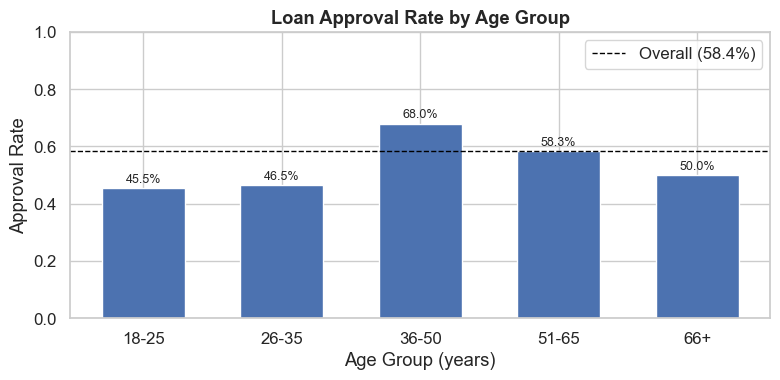

In [119]:
# bar chart: approval rate by age group
fig, ax = plt.subplots(figsize=(8, 4))

groups = age_rates.index.astype(str).tolist()
rates  = age_rates["approval_rate"].tolist()

bars = ax.bar(groups, rates, color="#4C72B0", edgecolor="white", width=0.6)
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1,
           label=f"Overall ({overall_rate:.1%})")

ax.set_title("Loan Approval Rate by Age Group", fontweight="bold")
ax.set_xlabel("Age Group (years)")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.legend()

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{rate:.1%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/02_approval_rate_by_age_group.png", dpi=150)
plt.show()

In [120]:
# Kruskal-Wallis test: does approval rate differ across age groups?
# H0: approval rate is equal across all age groups
# Non-parametric test used as loan_approved is binary
groups_data = [
    df.loc[df["age_group"] == g, "loan_approved"].dropna().astype(float).values
    for g in age_labels
    if len(df.loc[df["age_group"] == g, "loan_approved"].dropna()) > 0
]
h_stat, p_kruskal = stats.kruskal(*groups_data)

print(f"Kruskal-Wallis test across age groups")
print(f"H0: approval rate is equal across all age groups")
print(f"H = {h_stat:.4f},  p = {p_kruskal:.4f}")
print(f"Result: {'Reject H0' if p_kruskal < 0.05 else 'Fail to reject H0'} at alpha = 0.05")

Kruskal-Wallis test across age groups
H0: approval rate is equal across all age groups
H = 19.3810,  p = 0.0007
Result: Reject H0 at alpha = 0.05


Age-based bias summary:
- Approval rates are computed per age band (18-25, 26-35, 36-50, 51-65, 66+).
- The Kruskal-Wallis test assesses whether observed differences across age groups
  are statistically significant without assuming a normal distribution.
- Age-based patterns that persist after controlling for financial variables
  (income, DTI) would constitute evidence of age discrimination.

Option A — Flag age group with lowest approval rate for further review:
low_age_group = age_rates["approval_rate"].idxmin()

Option B — Include age as a control variable in logistic regression to
isolate its effect net of financial predictors.

### 5. Interest Rate Fairness
Even when approval rates are similar across groups, differential pricing — charging higher interest rates to a protected group — constitutes a form of disparate treatment. This section tests whether approved applicants from different gender groups receive systematically different interest rates.

In [122]:
# filter to approved applicants only
approved = df[df["loan_approved"] == True].copy()

# descriptive statistics for interest rate by gender
ir_by_gender = (
    approved.groupby("gender_clean", observed=True)["interest_rate"]
    .describe()
    .round(4)
)
print(f"Interest rate statistics by gender (n={len(approved)} approved applicants):")
display(ir_by_gender)

Interest rate statistics by gender (n=292 approved applicants):


,count,mean,std,min,25%,50%,75%,max
gender_clean,,,,,,,,
Female,127.0,4.4882,1.1929,2.5,3.4,4.4,5.55,6.5
Male,163.0,4.6282,1.1417,2.6,3.7,4.7,5.60,6.5


/var/folders/y3/q1l5v5v9335f6lmlzn4g_qjw0000gn/T/ipykernel_44846/1983082045.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=gender_groups, patch_artist=True,


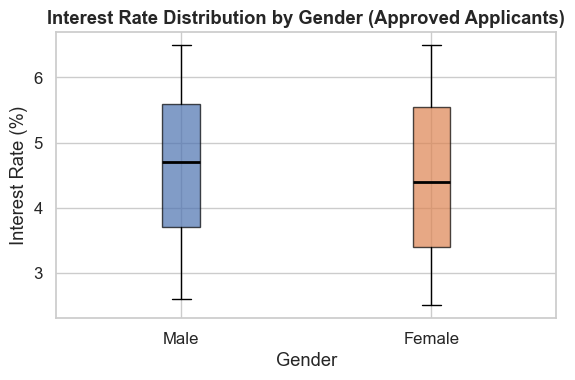

In [123]:
# box plot: interest rate distribution by gender (approved applicants only)
fig, ax = plt.subplots(figsize=(6, 4))

gender_groups = approved["gender_clean"].dropna().unique().tolist()
data_to_plot  = [approved.loc[approved["gender_clean"] == g, "interest_rate"].dropna().values
                 for g in gender_groups]

bp = ax.boxplot(data_to_plot, labels=gender_groups, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))

colors = ["#4C72B0", "#DD8452"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Interest Rate Distribution by Gender (Approved Applicants)", fontweight="bold")
ax.set_xlabel("Gender")
ax.set_ylabel("Interest Rate (%)")

plt.tight_layout()
plt.savefig("../reports/figures/02_interest_rate_by_gender.png", dpi=150)
plt.show()

In [124]:
# Welch's t-test: equal mean interest rates for male vs female approved applicants?
# H0: mean interest rate is equal for male and female approved applicants
# Welch's variant used because equal variance between groups is not assumed
male_ir   = approved.loc[approved["gender_clean"] == "Male",   "interest_rate"].dropna()
female_ir = approved.loc[approved["gender_clean"] == "Female", "interest_rate"].dropna()

t_stat, p_ttest = stats.ttest_ind(male_ir, female_ir, equal_var=False)

print(f"Welch's two-sample t-test")
print(f"H0: mean interest rate is equal for male and female approved applicants")
print(f"Male mean:   {male_ir.mean():.4f}  (n={len(male_ir)})")
print(f"Female mean: {female_ir.mean():.4f}  (n={len(female_ir)})")
print(f"t = {t_stat:.4f},  p = {p_ttest:.4f}")
print(f"Result: {'Reject H0' if p_ttest < 0.05 else 'Fail to reject H0'} at alpha = 0.05")

Welch's two-sample t-test
H0: mean interest rate is equal for male and female approved applicants
Male mean:   4.6282  (n=163)
Female mean: 4.4882  (n=127)
t = 1.0106,  p = 0.3132
Result: Fail to reject H0 at alpha = 0.05


Interest rate fairness summary:
- Analysis is restricted to approved applicants to isolate pricing bias from
  selection bias (which is captured separately by the DI ratio in Section 3).
- Welch's t-test is used rather than Student's t-test because equal variance
  between groups cannot be assumed a priori.
- A statistically significant difference in mean interest rates would indicate
  differential pricing — a form of disparate treatment even among approved
  applicants, with direct implications under ECOA and GDPR Article 22.

### 6. Proxy Discrimination — ZIP Code
Proxy discrimination occurs when a non-protected feature highly correlated with a protected characteristic influences decisions. ZIP code is a well-documented proxy for race and socioeconomic status in US lending. The dataset contains codes clustering around two geographic areas (NYC: 10xxx, LA: 90xxx).

In [126]:
# assign geographic region from ZIP code prefix
def classify_region(zip_code):
    if pd.isna(zip_code):
        return pd.NA
    z = str(zip_code)
    if z.startswith("10"):
        return "NYC (10xxx)"
    elif z.startswith("90"):
        return "LA (90xxx)"
    return "Other"

df["region"] = df["zip_code"].apply(classify_region)

# approval rate by region
region_rates = (
    df.groupby("region", observed=True)["loan_approved"]
    .agg(approved="sum", total="count", approval_rate="mean")
    .assign(approval_rate=lambda x: x["approval_rate"].round(4))
)
print("Approval rate by geographic region:")
display(region_rates)

Approval rate by geographic region:


,approved,total,approval_rate
region,,,
LA (90xxx),119,230,0.5174
NYC (10xxx),162,251,0.6454
Other,11,19,0.5789


In [127]:
# gender distribution by region — tests whether ZIP is a proxy for gender
region_gender = pd.crosstab(df["region"], df["gender_clean"], normalize="index").round(4)
print("Gender distribution by region (row-normalised):")
display(region_gender)

# chi-square test: is gender distribution independent of region?
# H0: gender and region are independent
ct = pd.crosstab(df["region"], df["gender_clean"])
chi2_rg, p_rg, dof_rg, _ = stats.chi2_contingency(ct)

print(f"\nChi-square test: gender x region")
print(f"H0: gender distribution is independent of region")
print(f"chi2 = {chi2_rg:.4f},  p = {p_rg:.4f},  dof = {dof_rg}")
print(f"Result: {'Reject H0 — ZIP acts as a gender proxy' if p_rg < 0.05 else 'Fail to reject H0'} at alpha = 0.05")

Gender distribution by region (row-normalised):


gender_clean,Female,Male
region,,
LA (90xxx),0.9348,0.0652
NYC (10xxx),0.1120,0.8880
Other,0.4444,0.5556



Chi-square test: gender x region
H0: gender distribution is independent of region
chi2 = 324.6681,  p = 0.0000,  dof = 2
Result: Reject H0 — ZIP acts as a gender proxy at alpha = 0.05


ZIP code proxy discrimination summary:
- ZIP codes cluster into NYC (10xxx) and LA (90xxx) geographic areas.
- If approval rates differ significantly between regions AND gender distribution
  is non-uniform across regions, ZIP code acts as a proxy for gender.
- The chi-square test on the gender x region contingency table formalises this.
- Even if ZIP is not an explicit model input, its correlation with the outcome
  may reflect geographic redlining patterns prohibited under the Fair Housing Act.

Option A — Remove ZIP code from any model feature set:
df_model = df.drop(columns=["zip_code", "region"])

Option B — Include region as a control variable in logistic regression
and compare its coefficient against non-geographic financial predictors.

### 7. Proxy Discrimination — Spending Behaviour
Granular spending categories may carry demographic signal. Categories such as spending_adult_entertainment, spending_gambling, and spending_alcohol warrant specific scrutiny: if these features differ systematically by gender, using them in credit scoring constitutes proxy discrimination and raises GDPR concerns about processing sensitive behavioural data.

In [129]:
# test whether sensitive spending categories differ significantly by gender
sensitive_cols = [
    "spending_adult_entertainment",
    "spending_gambling",
    "spending_alcohol",
]

results = []
for col in sensitive_cols:
    if col not in df.columns:
        continue
    male_vals   = df.loc[df["gender_clean"] == "Male",   col].dropna()
    female_vals = df.loc[df["gender_clean"] == "Female", col].dropna()
    t, p = stats.ttest_ind(male_vals, female_vals, equal_var=False)
    results.append({
        "feature":     col,
        "male_mean":   round(male_vals.mean(),   2),
        "female_mean": round(female_vals.mean(), 2),
        "male_n":      len(male_vals),
        "female_n":    len(female_vals),
        "t_statistic": round(t, 4),
        "p_value":     round(p, 4),
        "significant": p < 0.05,
    })

display(pd.DataFrame(results))

/var/folders/y3/q1l5v5v9335f6lmlzn4g_qjw0000gn/T/ipykernel_44846/2609773395.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t, p = stats.ttest_ind(male_vals, female_vals, equal_var=False)


,feature,male_mean,female_mean,male_n,female_n,t_statistic,p_value,significant
0,spending_adult_entertainment,658.50,322.00,4,1,NaN,NaN,False
1,spending_gambling,NaN,408.17,0,6,NaN,NaN,False
2,spending_alcohol,414.25,644.67,8,3,-1.8541,0.1291,False


Spending behaviour proxy summary:
- A statistically significant difference (p < 0.05) means the feature carries
  gender signal; including it in a scoring model encodes proxy discrimination.
- Under GDPR Article 9, processing behavioural data linked to gambling or adult
  content may require explicit consent and a legitimate legal basis.
- Even where statistical significance is absent, collecting these categories
  without a clear credit-relevance justification violates the data minimisation
  principle (GDPR Article 5(1)(c)).

Governance recommendation:
Exclude spending_adult_entertainment, spending_gambling, and spending_alcohol
from any model feature set until a lawful basis and necessity assessment is
completed by the data protection officer.

### 8. Interaction Effects
Bias often operates through the intersection of multiple protected attributes. This section examines approval rates at the intersection of gender and age group to identify whether specific demographic combinations face compounded disadvantage that would be invisible in a single-attribute analysis.

In [131]:
# approval rate by gender x age group
interaction = (
    df.groupby(["gender_clean", "age_group"], observed=True)["loan_approved"]
    .agg(approved="sum", total="count", approval_rate="mean")
    .assign(approval_rate=lambda x: x["approval_rate"].round(4))
)
print("Approval rate by gender x age group:")
display(interaction)

Approval rate by gender x age group:


approved  total  approval_rate
gender_clean age_group                                
Female       18-25             5     12         0.4167
             26-35            29     82         0.3537
             36-50            67    106         0.6321
             51-65            23     45         0.5111
             66+               2      4         0.5000
Male         18-25             5     10         0.5000
             26-35            44     75         0.5867
             36-50            86    119         0.7227
             51-65            25     38         0.6579
             66+               2      4         0.5000

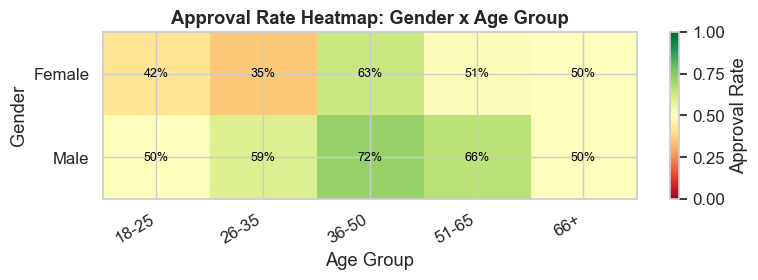

In [132]:
# heatmap: approval rate at intersection of gender and age group
pivot = interaction["approval_rate"].unstack(level="age_group")

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(pivot.values, cmap=plt.cm.RdYlGn, vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Approval Rate")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns.astype(str), rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index.tolist())

# annotate each cell with the approval rate
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        if not pd.isna(val):
            ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=9, color="black")

ax.set_title("Approval Rate Heatmap: Gender x Age Group", fontweight="bold")
ax.set_xlabel("Age Group")
ax.set_ylabel("Gender")

plt.tight_layout()
plt.savefig("../reports/figures/02_interaction_gender_age.png", dpi=150)
plt.show()

Interaction effects summary:
- Intersectional analysis reveals compounded disadvantage at specific gender x age
  combinations that single-attribute DI ratios cannot detect.
- The heatmap highlights cells with particularly low approval rates; these are
  candidates for targeted governance interventions.
- EU AI Act guidance for high-risk AI systems (credit scoring is explicitly listed
  in Annex III) requires evaluation of combined demographic effects.

### 9. Fairlearn Metrics
Fairlearn provides standardised fairness metrics that complement the manual DI ratio and statistical tests. Demographic Parity Difference (DPD) is the maximum difference in selection rates between any two groups; a value of 0 indicates perfect parity.

In [138]:
from fairlearn.metrics import demographic_parity_difference

# restrict to rows with non-null gender_clean and loan_approved
df_fair = df[df["gender_clean"].notna() & df["loan_approved"].notna()].copy()

# DPD using historical decisions — measures the disparity in NovaCred's actual outcomes
dpd = demographic_parity_difference(
    y_true=df_fair["loan_approved"],
    y_pred=df_fair["loan_approved"],
    sensitive_features=df_fair["gender_clean"],
)
print(f"Demographic Parity Difference (gender):  {dpd:.4f}")
print(f"Interpretation: 0 = perfect parity; |DPD| > 0.1 indicates meaningful concern")
print(f"Fairness concern: {'YES' if abs(dpd) > 0.1 else 'NO'} (|DPD|: {abs(dpd)})")

Demographic Parity Difference (gender):  0.1539
Interpretation: 0 = perfect parity; |DPD| > 0.1 indicates meaningful concern
Fairness concern: YES (|DPD|: 0.1539429327225511)


Fairlearn metrics summary:
- Demographic Parity Difference (DPD) = max(selection_rate) - min(selection_rate)
  across all gender groups.
- DPD and the DI ratio measure related but distinct properties:
    DI ratio:  unprivileged_rate / privileged_rate  (ratio; threshold at 0.8)
    DPD:       privileged_rate - unprivileged_rate  (difference; threshold ~0.1)
- Reporting both strengthens the regulatory argument by showing the pattern is
  robust to the choice of fairness metric.

### 10. Summary
All bias and fairness metrics computed in this notebook consolidated into a single reference table for use in the project report and video presentation.

In [136]:
summary_df = pd.DataFrame({
    "Metric": [
        "Overall approval rate",
        "Male approval rate",
        "Female approval rate",
        "Disparate Impact ratio (gender)",
        "Four-fifths rule violated",
        "Chi-square p-value (gender x approval)",
        "Interest rate — male mean (approved)",
        "Interest rate — female mean (approved)",
        "Welch t-test p-value (interest rate by gender)",
        "Demographic Parity Difference (Fairlearn)",
    ],
    "Value": [
        f"{overall_rate:.1%}",
        f"{male_rate:.1%}",
        f"{female_rate:.1%}",
        f"{di_ratio:.4f}",
        "YES" if di_ratio < 0.8 else "NO",
        f"{p_value:.4f}",
        f"{male_ir.mean():.4f}",
        f"{female_ir.mean():.4f}",
        f"{p_ttest:.4f}",
        f"{dpd:.4f}",
    ],
    "Threshold / Interpretation": [
        "—",
        "—",
        "—",
        "< 0.80 = potential disparate impact",
        "—",
        "< 0.05 = statistically significant",
        "—",
        "—",
        "< 0.05 = statistically significant",
        "|DPD| > 0.1 = fairness concern",
    ],
})
display(summary_df)

,Metric,Value,Threshold / Interpretation
0,Overall approval rate,58.4%,—
1,Male approval rate,66.0%,—
2,Female approval rate,50.6%,—
3,Disparate Impact ratio (gender),0.7668,< 0.80 = potential disparate impact
4,Four-fifths rule violated,YES,—
5,Chi-square p-value (gender x approval),0.0007,< 0.05 = statistically significant
6,Interest rate — male mean (approved),4.6282,—
7,Interest rate — female mean (approved),4.4882,—
8,Welch t-test p-value (interest rate by gender),0.3132,< 0.05 = statistically significant
9,Demographic Parity Difference (Fairlearn),0.1539,|DPD| > 0.1 = fairness concern


In [137]:
# summary of all bias findings with regulatory status
findings_df = pd.DataFrame({
    "Finding": [
        "Gender Disparate Impact ratio",
        "Gender bias significance",
        "Age group bias significance",
        "Interest rate pricing by gender",
        "Demographic Parity Difference",
        "Geographic proxy (ZIP code)",
    ],
    "Metric": [
        "DI = female rate / male rate",
        "Chi-square p-value",
        "Kruskal-Wallis p-value",
        "Welch t-test p-value",
        "DPD (Fairlearn)",
        "Approval rate gap NYC vs. LA",
    ],
    "Value": [
        f"{di_ratio:.4f}",
        f"{p_value:.4f}",
        f"{p_kruskal:.4f}",
        f"{p_ttest:.4f}",
        f"{dpd:.4f}",
        f"{region_rates.loc['NYC (10xxx)', 'approval_rate'] - region_rates.loc['LA (90xxx)', 'approval_rate']:.1%}",
    ],
    "Threshold": [
        "< 0.80 = violation",
        "< 0.05 = significant",
        "< 0.05 = significant",
        "< 0.05 = significant",
        "> 0.10 = concern",
        "—",
    ],
    "Status": [
        "VIOLATION" if di_ratio < 0.8 else "OK",
        "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT",
        "SIGNIFICANT" if p_kruskal < 0.05 else "NOT SIGNIFICANT",
        "SIGNIFICANT" if p_ttest < 0.05 else "No bias detected",
        "CONCERN" if abs(dpd) > 0.1 else "OK",
        "Investigate",
    ],
})
display(findings_df)

,Finding,Metric,Value,Threshold,Status
0,Gender Disparate Impact ratio,DI = female rate / male rate,0.7668,< 0.80 = violation,VIOLATION
1,Gender bias significance,Chi-square p-value,0.0007,< 0.05 = significant,SIGNIFICANT
2,Age group bias significance,Kruskal-Wallis p-value,0.0007,< 0.05 = significant,SIGNIFICANT
3,Interest rate pricing by gender,Welch t-test p-value,0.3132,< 0.05 = significant,No bias detected
4,Demographic Parity Difference,DPD (Fairlearn),0.1539,> 0.10 = concern,CONCERN
5,Geographic proxy (ZIP code),Approval rate gap NYC vs. LA,12.8%,—,Investigate
